# Notebook 08 - Final Submission

## Objective

Train the final selected model on the complete training dataset and generate predictions for the unseen test dataset.

The predictions will be exported in the required competition submission format.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [2]:
train = pd.read_csv("../data/processed/train_selected.csv")

test = pd.read_csv("../data/processed/test_selected.csv")

print(train.shape)

print(test.shape)

(150, 5)
(50, 4)


In [3]:
X_train = train.drop(columns="overall_yield")

y_train = train["overall_yield"]

X_test = test.copy()

In [4]:
model = joblib.load("../models/final_model_final.pkl")

model

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('cat', ...), ('extra', ...)]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.","[3, 1]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
estimators_ estimators_: list of regressorsThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'.,list,"[CatBoostRegre...=1, verbose=0), ExtraTreesReg...ndom_state=42)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['inlet_temperature_K','jacket_temperature_K','temp_difference', 'residence_time_proxy']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying regressor exposes such an attribute when fit... versionadded:: 0.24,int,0
named_estimators_ named_estimators_: :class:`~sklearn.utils.Bunch`Attribute to access any fitted sub-estimators by name... versionadded:: 0.20,Bunch,{'cat': CatBo...dom_state=42)}
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",700
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20


In [5]:
model.fit(
    X_train,
    y_train
)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('cat', ...), ('extra', ...)]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.","[3, 1]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
estimators_ estimators_: list of regressorsThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'.,list,"[CatBoostRegre...=1, verbose=0), ExtraTreesReg...ndom_state=42)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['inlet_temperature_K','jacket_temperature_K','temp_difference', 'residence_time_proxy']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying regressor exposes such an attribute when fit... versionadded:: 0.24,int,4
named_estimators_ named_estimators_: :class:`~sklearn.utils.Bunch`Attribute to access any fitted sub-estimators by name... versionadded:: 0.20,Bunch,{'cat': CatBo...dom_state=42)}
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",700
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20


In [7]:
predictions = model.predict(X_test)

print("Predictions generated:", len(predictions))
print(predictions[:10])

Predictions generated: 50
[36.11253328 83.90087465 13.63898802 81.63281269  1.62299442 58.48346351
 85.60533568 70.75186099  3.08764646 55.02140274]


In [9]:
submission = pd.DataFrame({

    "overall_yield": np.round(predictions, 3)

})

submission.head()

,overall_yield
0,36.113
1,83.901
2,13.639
3,81.633
4,1.623


In [10]:
print("Shape")

print(submission.shape)

print()

print("Columns")

print(submission.columns)

print()

print("Missing Values")

print(submission.isnull().sum())

Shape
(50, 1)

Columns
Index(['overall_yield'], dtype='str')

Missing Values
overall_yield    0
dtype: int64


In [11]:
submission.to_csv(

    "../submissions/FugX_Final.csv",

    index=False

)

print("Submission saved successfully!")

Submission saved successfully!


In [12]:
submission

,overall_yield
0,36.113
1,83.901
2,13.639
3,81.633
4,1.623
5,58.483
6,85.605
7,70.752
8,3.088
9,55.021


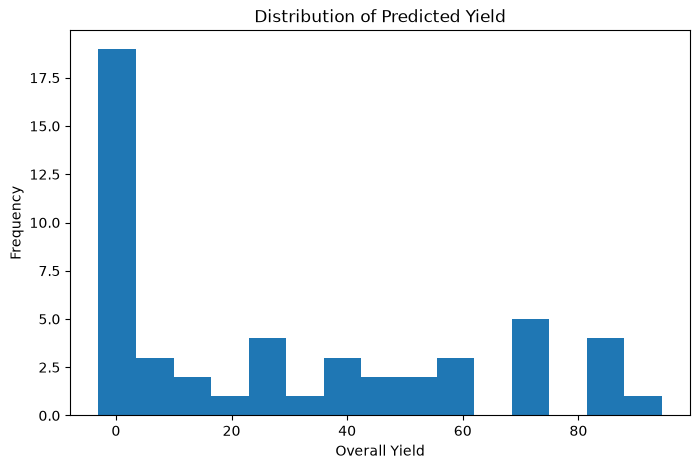

In [13]:
plt.figure(figsize=(8,5))

plt.hist(predictions, bins=15)

plt.title("Distribution of Predicted Yield")

plt.xlabel("Overall Yield")

plt.ylabel("Frequency")

plt.show()

In [14]:
submission.describe()

,overall_yield
count,50.00000
mean,30.15074
std,31.19245
min,-3.03700
25%,2.46200
50%,22.50300
75%,57.65400
max,94.45700


In [15]:
assert submission.shape[0] == 50

assert submission.columns.tolist() == ["overall_yield"]

assert submission.isnull().sum().sum() == 0

print("Submission validated successfully!")

Submission validated successfully!


In [17]:
import os

path = "../submissions/FugX_Final.csv"

print("File exists:", os.path.exists(path))

if os.path.exists(path):
    print("File size:", os.path.getsize(path), "bytes")

File exists: True
File size: 396 bytes


In [19]:
final_csv = pd.read_csv("../submissions/FugX_Final.csv")

print("Shape:", final_csv.shape)
print("Columns:", final_csv.columns.tolist())
print("Missing values:")
print(final_csv.isnull().sum())

print("\nFirst 10 predictions:")
display(final_csv.head(10))

print("\nLast 10 predictions:")
display(final_csv.tail(10))

Shape: (50, 1)
Columns: ['overall_yield']
Missing values:
overall_yield    0
dtype: int64

First 10 predictions:


,overall_yield
0,36.113
1,83.901
2,13.639
3,81.633
4,1.623
5,58.483
6,85.605
7,70.752
8,3.088
9,55.021



Last 10 predictions:


,overall_yield
40,-2.334
41,31.374
42,1.712
43,3.115
44,71.747
45,94.457
46,2.669
47,0.037
48,25.494
49,2.326


In [21]:
assert len(final_csv) == 50
assert final_csv.columns.tolist() == ["overall_yield"]
assert final_csv["overall_yield"].notna().all()

print("✅ FINAL CSV VALIDATION PASSED")

✅ FINAL CSV VALIDATION PASSED


In [22]:
print(final_csv["overall_yield"].describe())

count    50.00000
mean     30.15074
std      31.19245
min      -3.03700
25%       2.46200
50%      22.50300
75%      57.65400
max      94.45700
Name: overall_yield, dtype: float64


In [23]:
final_csv = pd.read_csv("../submissions/FugX_Final.csv")

assert final_csv.shape == (50, 1)
assert final_csv.columns.tolist() == ["overall_yield"]
assert final_csv["overall_yield"].notna().all()

print("✅ FINAL SUBMISSION VERIFIED")
print(final_csv.head())

✅ FINAL SUBMISSION VERIFIED
   overall_yield
0         36.113
1         83.901
2         13.639
3         81.633
4          1.623


In [ ]:
final_csv = pd.read_csv("../submissions/FugX_Final.csv")

print(final_csv.shape)
print(final_csv.columns)
print(final_csv.isna().sum())